<a href="https://colab.research.google.com/github/marwa-nassane0052/quantum_ai_experiment/blob/main/test3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation'

if os.path.exists(folder_path):
    print(f"Contents of '{folder_path}':")
    for item in os.listdir(folder_path):
        print(item)
else:
    print(f"Folder '{folder_path}' not found. Please check the path and ensure it's in your My Drive.")

Contents of '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation':
y_train.npy
y_test.npy
X_train.npy
X_test.npy


In [3]:
import numpy as np
folder_path = '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation'
X_train = np.load(os.path.join(folder_path, 'X_train.npy'))
y_train = np.load(os.path.join(folder_path, 'y_train.npy'))
X_test = np.load(os.path.join(folder_path, 'X_test.npy'))
y_test = np.load(os.path.join(folder_path, 'y_test.npy'))

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2200, 3, 128, 128)
y_train shape: (2200,)
X_test shape: (660, 3, 128, 128)
y_test shape: (660,)


**Bulding the hybrid model**

In [4]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.6 MB/s eta 0:00:00


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from torch.utils.data import TensorDataset, DataLoader

import numpy as np

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

import pennylane as qml
import torch

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='X')

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class QuantumLayer(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qlayer

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            outputs.append(self.qlayer(x[i]))
        return torch.stack(outputs)

#the hubride model
import torch.nn as nn
import torch.nn.functional as F

class HybridModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3)

        self.fc1 = nn.Linear(32*30*30, n_qubits)

        self.quantum = QuantumLayer()

        self.fc2 = nn.Linear(n_qubits, 2)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.shape[0], -1)

        x = self.fc1(x)

        x = self.quantum(x)

        x = self.fc2(x)

        return x
#initlize the model
model = HybridModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()




/tmp/ipykernel_479/4016412383.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_479/4016412383.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_479/4016412383.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_479/4016412383.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or s

In [8]:
for epoch in range(20):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f} | Train Acc={train_acc:.2f}% | Test Acc={test_acc:.2f}%")

Epoch 1: Loss=0.6782 | Train Acc=57.64% | Test Acc=68.79%
Epoch 2: Loss=0.6241 | Train Acc=74.73% | Test Acc=76.97%
Epoch 3: Loss=0.5753 | Train Acc=77.68% | Test Acc=78.18%
Epoch 4: Loss=0.5202 | Train Acc=80.41% | Test Acc=80.00%
Epoch 5: Loss=0.4612 | Train Acc=81.55% | Test Acc=79.09%
Epoch 6: Loss=0.4497 | Train Acc=81.45% | Test Acc=81.67%
Epoch 7: Loss=0.4154 | Train Acc=82.64% | Test Acc=81.52%
Epoch 8: Loss=0.3830 | Train Acc=83.59% | Test Acc=82.42%
Epoch 9: Loss=0.3880 | Train Acc=83.05% | Test Acc=81.36%
Epoch 10: Loss=0.3793 | Train Acc=83.27% | Test Acc=83.33%
Epoch 11: Loss=0.3380 | Train Acc=85.68% | Test Acc=80.30%
Epoch 12: Loss=0.3366 | Train Acc=86.50% | Test Acc=81.21%
Epoch 13: Loss=0.3139 | Train Acc=87.09% | Test Acc=83.64%
Epoch 14: Loss=0.2684 | Train Acc=89.09% | Test Acc=81.67%
Epoch 15: Loss=0.2647 | Train Acc=89.32% | Test Acc=82.73%
Epoch 16: Loss=0.2412 | Train Acc=90.36% | Test Acc=83.33%
Epoch 17: Loss=0.2235 | Train Acc=91.86% | Test Acc=82.58%
Epoch 

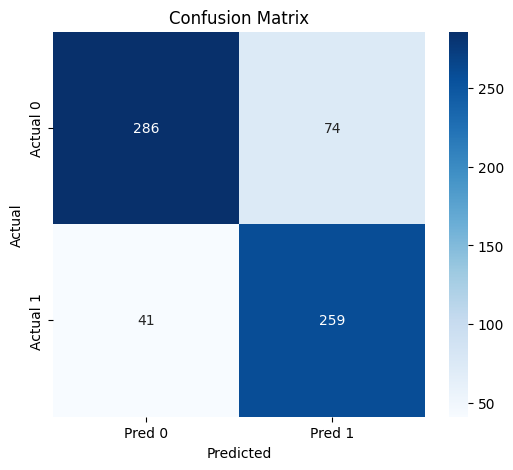

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = [[286, 74],
      [41, 259]]

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

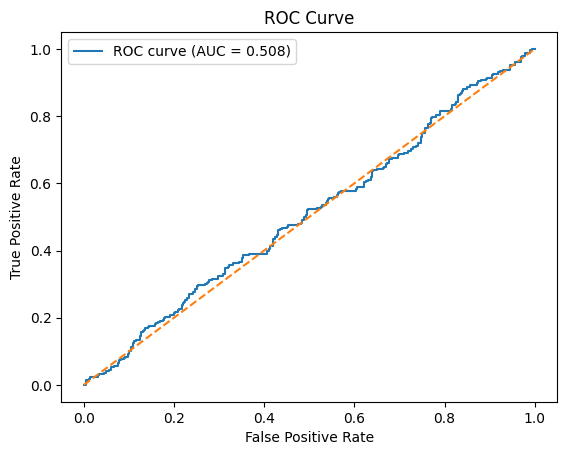

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Example probabilities (replace with your model predictions)
y_true = np.concatenate([np.zeros(360), np.ones(300)])

# Example scores placeholder
y_scores = np.random.rand(660)

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Class 0","Class 1"]
))

import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["Class 0","Class 1"],
    output_dict=True
)

df = pd.DataFrame(report).transpose()

print(df)

              precision    recall  f1-score   support

     Class 0       0.85      0.78      0.81       360
     Class 1       0.75      0.83      0.79       300

    accuracy                           0.80       660
   macro avg       0.80      0.80      0.80       660
weighted avg       0.80      0.80      0.80       660

              precision  recall  f1-score  support
Class 0        0.845455  0.7750  0.808696    360.0
Class 1        0.754545  0.8300  0.790476    300.0
accuracy       0.800000  0.8000  0.800000      0.8
macro avg      0.800000  0.8025  0.799586    660.0
weighted avg   0.804132  0.8000  0.800414    660.0
